# Importing borders of the property

In [14]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import folium

print("OSMnx", ox.__version__)

OSMnx 2.1.1


In [15]:
center_b = [14.444971, 120.999328]

lat, lon = center_b

In [16]:
print(f"Latitude: {lat}")
print(f"Longitude: {lon}")

Latitude: 14.444971
Longitude: 120.999328


In [17]:
tags = {
    "building": True,
    "Landuse": True,
    "boundary": True,
    "amenity": True,
    "laisure": True,
    "place": True,
    }

gdf = ox.features_from_point(
    (lat, lon),
    tags=tags,
    dist=100
)



print(f"Features found: {len(gdf)}")

Features found: 39


In [18]:
print(gdf.columns.tolist())

['geometry', 'admin_level', 'name', 'old_ref', 'place', 'population', 'population:date', 'ref', 'wikidata', 'boundary', 'amenity', 'access', 'fee', 'parking', 'building', 'building:part', 'layer', 'building:levels', 'construction', 'height', 'type', 'border_type', 'postal_code', 'landuse']


In [20]:
#display(gdf)

In [21]:
landuse = gdf[
    gdf["landuse"].notna()
].copy()

print(f"Landuse: {len(landuse)}")

Landuse: 1


<Axes: >

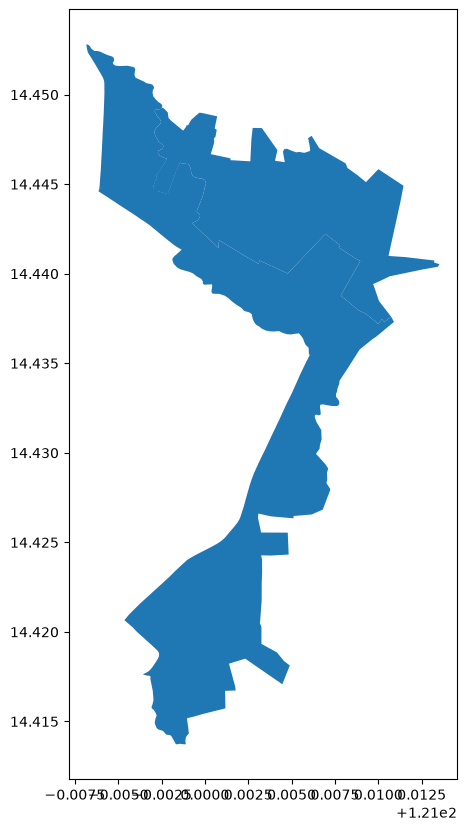

In [23]:
gdf.plot(figsize=(10, 10))

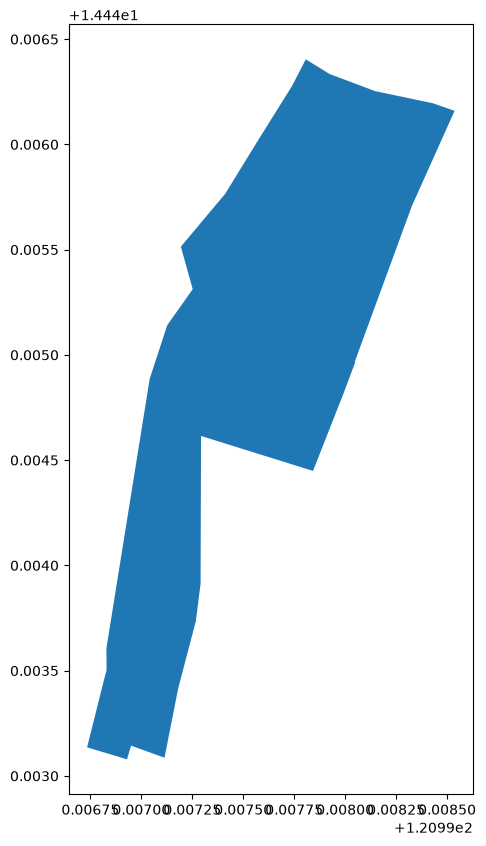

In [24]:
ax = gdf[gdf["landuse"].notna()].plot(figsize=(10, 10))

In [34]:
m = folium.Map(
    location=[lat, lon],
    zoom_start=16,
    
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}", attr="Esri"
)

folium.CircleMarker(
    location=[lat, lon],
    radius=8,
    color="red",
    fill=True,
    fill_opacity=1
).add_to(m)

m

In [37]:
tags = {
    "landuse": "residential"
}

residential = ox.features_from_point(
    (lat, lon),
    tags=tags,
    dist=100
)

print(f"residential: {len(residential)}")


residential: 6


In [38]:
print(residential.geometry.geom_type.value_counts())

Polygon    6
Name: count, dtype: int64


<Axes: >

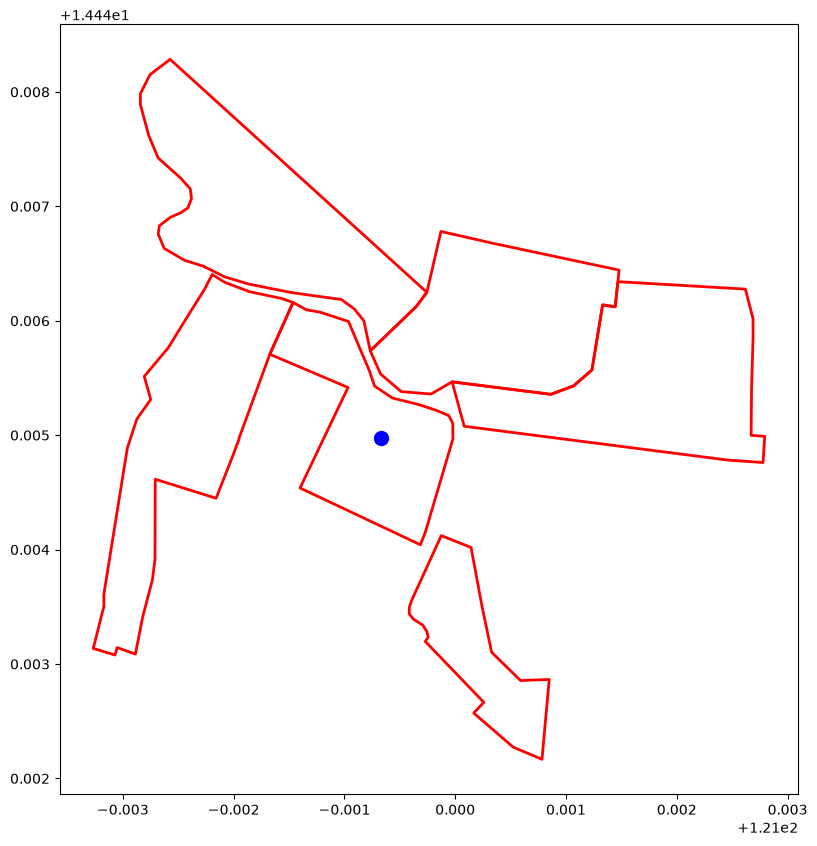

In [39]:
ax = residential.plot(
    figsize=(10, 10),
    edgecolor="red",
    facecolor="none",
    linewidth=2
)

gpd.GeoSeries(
    [Point(lon, lat)],
    crs="EPSG:4326",
).plot(
    ax=ax,
    color="blue",
    markersize=100
)

In [41]:
property_point = gpd.GeoSeries(
    [Point(lon, lat)],
    crs="EPSG:4326",
)

matches = residential[
    residential.geometry.contains(
        property_point.iloc[0]
    )
]

print(f"Polygin: {len(matches)}")

Polygin: 1


<Axes: >

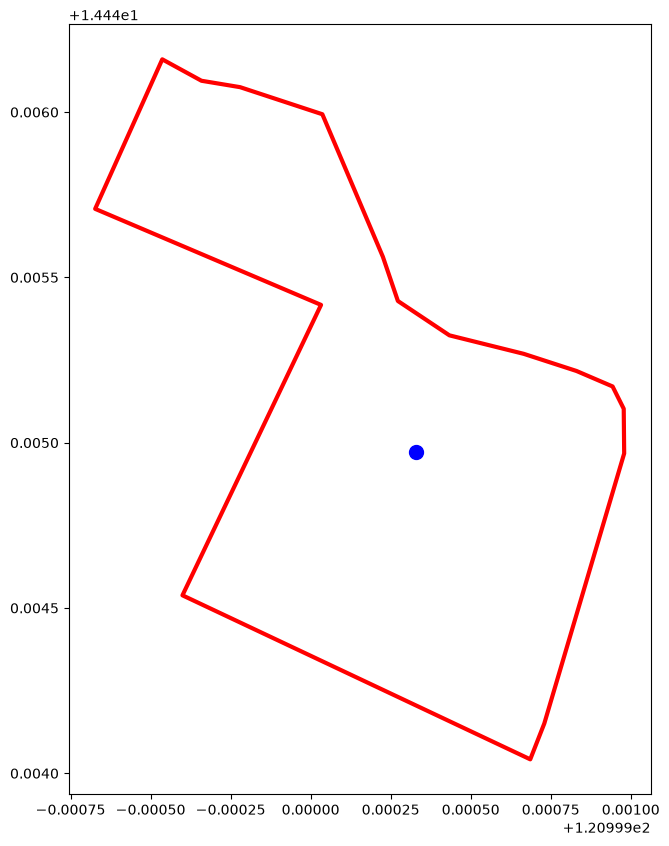

In [42]:
ax = matches.plot(
    figsize=(10, 10),
    edgecolor="red",
    facecolor="none",
    linewidth=3
)

property_point.plot(
    ax=ax,
    color="blue",
    markersize=100
)

In [45]:
residential = ox.features_from_point(
    (lat, lon),
    tags={"landuse": "residential"},
    dist=100
)

print(f"features: {len(residential)}")

features: 6


In [48]:
property_point = Point(lon, lat)

matches = residential[
    residential.geometry.intersects(property_point)
]

print(f"Matches: {len(matches)}")

Matches: 1


In [49]:
if not matches.empty:
    geometry = matches.geometry.iloc[0]
    print(f"Geometry: {geometry.geom_type}")

Geometry: Polygon
